# Chapter 11: Reward Modeling — Teaching the VLM What "Good" Means

*Build a Multimodal Model from Scratch · Chapter 11*

> **This chapter in context:** Ch03-04 trained a VLM to generate captions by maximising next-token prediction — the model learns to output plausible text, but "plausible" is not the same as "correct". This chapter builds a Reward Model that assigns a higher scalar score to preferred outputs than to rejected ones, using the Bradley-Terry pairwise preference framework. This is Step 1 of RLHF and the foundation for Ch12 (DPO and GRPO).

In [1]:
%matplotlib inline
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import math, copy
torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9', orange='#E67E22',
           green='#27AE60', red='#E74C3C', purple='#8E44AD', grey='#95A5A6')
VOCAB = ["<pad>","<bos>","<eos>","a","red","blue","green","yellow",
         "circle","square","triangle","star","correct","wrong","good","bad"]
w2i = {w:i for i,w in enumerate(VOCAB)}
i2w = {i:w for i,w in enumerate(VOCAB)}
print(f"Device: {DEVICE}  |  Vocab size: {len(VOCAB)}")

Device: cpu  |  Vocab size: 16


## Problem 1 — SFT Has No Notion of Quality

Supervised fine-tuning (Ch03-04) trains the VLM with a cross-entropy loss over next-token predictions. Every token prediction is treated equally: if the model generates "a blue square" for an image of a red circle, the loss is non-zero but it encodes no information about *how wrong* the output is. The model has no quality signal — it just tries to match the training distribution.

Consider two responses to an image of a red circle:
- **Preferred** (y_w): "a red circle" — factually correct
- **Rejected** (y_l): "a blue square" — completely wrong

Under SFT, both responses generate a loss, but the SFT model only sees the *correct* caption during training — it never sees y_l at all. There is no mechanism to teach the model that y_w is *better* than y_l by some margin.

**The solution:** train a separate model — the Reward Model — that takes (image, caption) as input and outputs a scalar quality score. The only requirement: the score for the preferred response must be higher than the score for the rejected response.

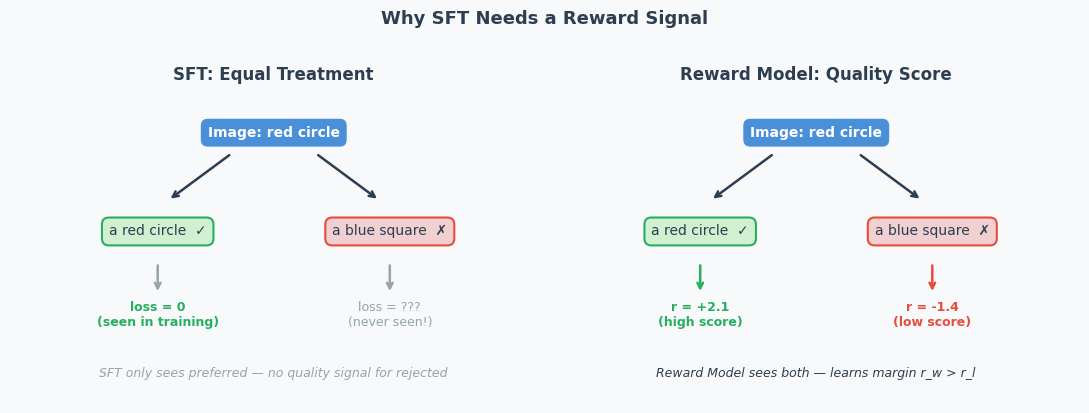

In [2]:
def draw_alignment_problem():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.patch.set_facecolor(PAL['bg'])

    for ax in axes:
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 6)
        ax.axis('off')
        ax.set_facecolor(PAL['bg'])

    arw = dict(arrowstyle='->', lw=1.8)

    # --- Left panel: SFT treats all tokens equally ---
    ax = axes[0]
    ax.set_title('SFT: Equal Treatment', fontsize=12, fontweight='bold',
                 color=PAL['dark'], pad=8)

    # Image box
    ax.text(5, 5.2, 'Image: red circle', ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=PAL['blue'], lw=0),
            color='white', fontweight='bold')

    # Arrow down
    ax.annotate('', xy=(3, 3.9), xytext=(4.2, 4.8), arrowprops=dict(**arw, color=PAL['dark']))
    ax.annotate('', xy=(7, 3.9), xytext=(5.8, 4.8), arrowprops=dict(**arw, color=PAL['dark']))

    # Preferred box
    ax.text(2.8, 3.3, 'a red circle  ✓', ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#d0f0d0', lw=1.5, edgecolor=PAL['green']),
            color=PAL['dark'])

    # Rejected box
    ax.text(7.2, 3.3, 'a blue square  ✗', ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0d0d0', lw=1.5, edgecolor=PAL['red']),
            color=PAL['dark'])

    # SFT loss arrows — equal
    ax.annotate('', xy=(2.8, 2.1), xytext=(2.8, 2.7), arrowprops=dict(**arw, color=PAL['grey']))
    ax.annotate('', xy=(7.2, 2.1), xytext=(7.2, 2.7), arrowprops=dict(**arw, color=PAL['grey']))

    ax.text(2.8, 1.7, 'loss = 0\n(seen in training)', ha='center', va='center',
            fontsize=9, color=PAL['green'], fontweight='bold')
    ax.text(7.2, 1.7, 'loss = ???\n(never seen!)', ha='center', va='center',
            fontsize=9, color=PAL['grey'])

    ax.text(5, 0.5, 'SFT only sees preferred — no quality signal for rejected',
            ha='center', fontsize=9, color=PAL['grey'], style='italic')

    # --- Right panel: Reward Model distinguishes ---
    ax = axes[1]
    ax.set_title('Reward Model: Quality Score', fontsize=12, fontweight='bold',
                 color=PAL['dark'], pad=8)

    ax.text(5, 5.2, 'Image: red circle', ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=PAL['blue'], lw=0),
            color='white', fontweight='bold')

    ax.annotate('', xy=(3, 3.9), xytext=(4.2, 4.8), arrowprops=dict(**arw, color=PAL['dark']))
    ax.annotate('', xy=(7, 3.9), xytext=(5.8, 4.8), arrowprops=dict(**arw, color=PAL['dark']))

    ax.text(2.8, 3.3, 'a red circle  ✓', ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#d0f0d0', lw=1.5, edgecolor=PAL['green']),
            color=PAL['dark'])

    ax.text(7.2, 3.3, 'a blue square  ✗', ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0d0d0', lw=1.5, edgecolor=PAL['red']),
            color=PAL['dark'])

    ax.annotate('', xy=(2.8, 2.1), xytext=(2.8, 2.7), arrowprops=dict(**arw, color=PAL['green']))
    ax.annotate('', xy=(7.2, 2.1), xytext=(7.2, 2.7), arrowprops=dict(**arw, color=PAL['red']))

    ax.text(2.8, 1.7, 'r = +2.1\n(high score)', ha='center', va='center',
            fontsize=9, color=PAL['green'], fontweight='bold')
    ax.text(7.2, 1.7, 'r = -1.4\n(low score)', ha='center', va='center',
            fontsize=9, color=PAL['red'], fontweight='bold')

    ax.text(5, 0.5, 'Reward Model sees both — learns margin r_w > r_l',
            ha='center', fontsize=9, color=PAL['dark'], style='italic')

    plt.suptitle('Why SFT Needs a Reward Signal', fontsize=13, fontweight='bold',
                 color=PAL['dark'], y=1.02)
    plt.tight_layout()
    plt.show()

draw_alignment_problem()

## Problem 2 — What Does a Preference Dataset Look Like?

A preference dataset consists of triples `(x, y_w, y_l)` where:
- `x` is the input (here: an image)
- `y_w` is the **preferred** ("winning") response — annotated as better
- `y_l` is the **rejected** ("losing") response — annotated as worse

The annotation just says "y_w is better than y_l" — **no numeric score is needed**. This is much easier to collect from human annotators than asking "rate this response from 1 to 10".

For our synthetic dataset:
- **Input**: a 32×32 image of one of 4 scene classes (red circle, blue square, green triangle, yellow star)
- **Preferred caption** (y_w): the caption that correctly describes the image
- **Rejected caption** (y_l): the caption for a randomly chosen *different* class

Each training sample is a triple `(image, preferred_token_ids, rejected_token_ids)`.

Caption format: `["<bos>", "a", "<color>", "<shape>", "<eos>"]`

In [3]:
def make_image(cls, size=32, noise=0.05):
    """Generate synthetic image for class 0=red circle, 1=blue square, 2=green triangle, 3=yellow star"""
    img = np.zeros((size, size, 3), dtype=np.float32)
    colors = [(1,0,0),(0,0,1),(0,0.7,0),(1,0.8,0)]
    c = colors[cls]
    h, w = size//2, size//2
    r = size//4
    if cls == 0:  # circle
        for i in range(size):
            for j in range(size):
                if (i-h)**2 + (j-w)**2 < r**2: img[i,j] = c
    elif cls == 1:  # square
        img[h-r:h+r, w-r:w+r] = c
    elif cls == 2:  # triangle
        for i in range(h-r, h+r):
            wid = int((i-(h-r))/(2*r) * 2*r)
            img[i, w-wid:w+wid] = c
    else:  # star (diamond)
        for i in range(size):
            for j in range(size):
                if abs(i-h)+abs(j-w) < r: img[i,j] = c
    img += (np.random.randn(*img.shape) * noise).astype(np.float32)
    return np.clip(img, 0, 1)

CAPTIONS = [
    ["<bos>","a","red","circle","<eos>"],
    ["<bos>","a","blue","square","<eos>"],
    ["<bos>","a","green","triangle","<eos>"],
    ["<bos>","a","yellow","star","<eos>"],
]

class PreferenceDataset(Dataset):
    def __init__(self, n_per_class=40, seed=0):
        rng = np.random.RandomState(seed)
        self.samples = []
        for cls in range(4):
            for _ in range(n_per_class):
                img = torch.from_numpy(make_image(cls)).permute(2,0,1)
                y_w = [w2i[t] for t in CAPTIONS[cls]]
                # Rejected: random wrong class
                rej_cls = (cls + 1 + rng.randint(3)) % 4
                y_l = [w2i[t] for t in CAPTIONS[rej_cls]]
                self.samples.append((img, torch.tensor(y_w), torch.tensor(y_l), cls))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

dataset = PreferenceDataset(n_per_class=40)
print(f"Dataset: {len(dataset)} preference pairs")
print(f"Sample preferred: {[i2w[t] for t in dataset[0][1].tolist()]}")
print(f"Sample rejected:  {[i2w[t] for t in dataset[0][2].tolist()]}")

Dataset: 160 preference pairs
Sample preferred: ['<bos>', 'a', 'red', 'circle', '<eos>']
Sample rejected:  ['<bos>', 'a', 'blue', 'square', '<eos>']


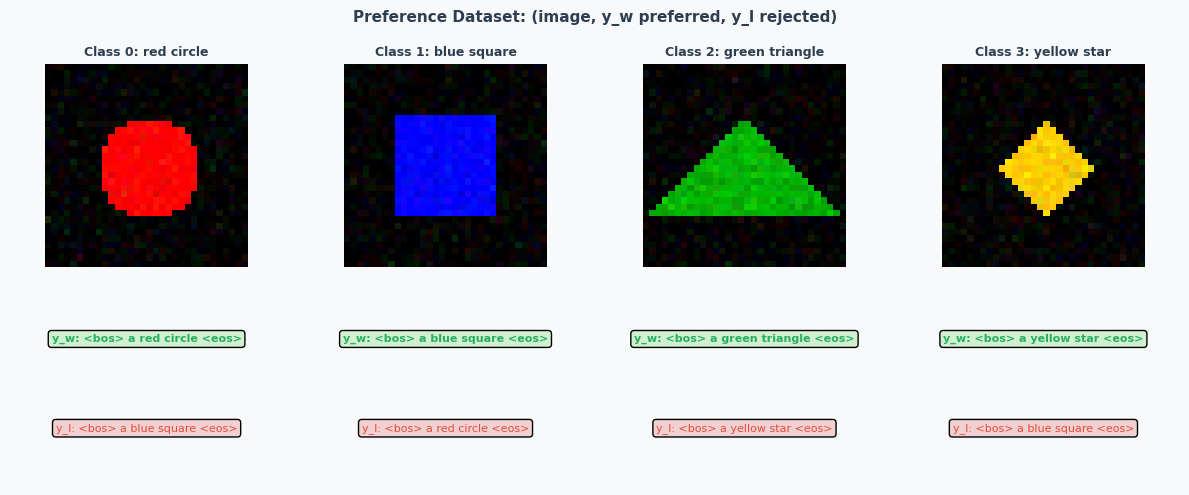

In [4]:
# Visualise 4 preference pairs (one per class)
fig, axes = plt.subplots(2, 4, figsize=(12, 5))
fig.patch.set_facecolor(PAL['bg'])

class_names = ["red circle", "blue square", "green triangle", "yellow star"]

for cls in range(4):
    # Find first sample of this class
    idx = cls * 40
    img, y_w, y_l, label = dataset[idx]

    preferred_str = ' '.join(i2w[t] for t in y_w.tolist() if i2w[t] not in ('<pad>',))
    rejected_str  = ' '.join(i2w[t] for t in y_l.tolist() if i2w[t] not in ('<pad>',))

    # Top row: image
    ax_img = axes[0, cls]
    ax_img.imshow(img.permute(1,2,0).numpy().clip(0,1))
    ax_img.set_title(f'Class {cls}: {class_names[cls]}', fontsize=9,
                     fontweight='bold', color=PAL['dark'])
    ax_img.axis('off')

    # Bottom row: preference pair
    ax_cap = axes[1, cls]
    ax_cap.axis('off')
    ax_cap.set_facecolor(PAL['bg'])
    ax_cap.text(0.5, 0.72, f'y_w: {preferred_str}', ha='center', va='center',
                fontsize=8, color=PAL['green'], fontweight='bold',
                transform=ax_cap.transAxes,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#d0f0d0', lw=1))
    ax_cap.text(0.5, 0.28, f'y_l: {rejected_str}', ha='center', va='center',
                fontsize=8, color=PAL['red'],
                transform=ax_cap.transAxes,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0d0d0', lw=1))

axes[0, 0].set_ylabel('Image', fontsize=9, color=PAL['dark'])
axes[1, 0].set_ylabel('Preference\nPair', fontsize=9, color=PAL['dark'])

plt.suptitle('Preference Dataset: (image, y_w preferred, y_l rejected)',
             fontsize=11, fontweight='bold', color=PAL['dark'])
plt.tight_layout()
plt.show()

## Problem 3 — The Bradley-Terry Model

We need a principled way to turn pairwise annotations ("y_w is better than y_l") into a trainable objective.

The **Bradley-Terry model** (1952) provides exactly this. It assumes:
1. Each (input, response) pair has a latent quality score `r(x, y)`
2. The probability that y_w is preferred over y_l given input x is:

$$P(y_w \succ y_l \mid x) = \sigma(r(x, y_w) - r(x, y_l))$$

where $\sigma$ is the sigmoid function.

**Training objective**: maximise the log-likelihood of observed preferences:

$$\mathcal{L}_{BT} = -\log \sigma(r(x, y_w) - r(x, y_l))$$

This is just binary cross-entropy on the **margin** between the two reward scores.

**Key insight**: the loss only depends on the *difference* `r_w - r_l`, not their absolute values. The reward model learns to *rank*, not to predict a specific score. This means:
- margin = 0 → 50% probability, random chance (no preference learned)
- margin → +∞ → 100% probability (perfect preference)
- The absolute scale of rewards is arbitrary; only relative ordering matters

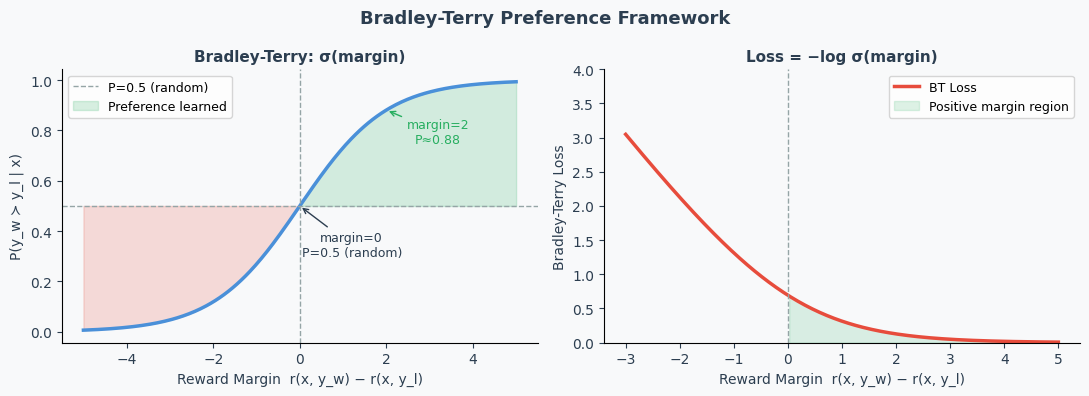

In [5]:
def draw_bradley_terry():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.patch.set_facecolor(PAL['bg'])

    # Left: sigmoid curve
    ax = axes[0]
    ax.set_facecolor(PAL['bg'])
    margins = np.linspace(-5, 5, 300)
    probs = 1 / (1 + np.exp(-margins))
    ax.plot(margins, probs, color=PAL['blue'], lw=2.5)
    ax.axhline(0.5, color=PAL['grey'], linestyle='--', lw=1, label='P=0.5 (random)')
    ax.axvline(0, color=PAL['grey'], linestyle='--', lw=1)
    ax.fill_between(margins, 0.5, probs, where=(probs > 0.5),
                    alpha=0.18, color=PAL['green'], label='Preference learned')
    ax.fill_between(margins, probs, 0.5, where=(probs < 0.5),
                    alpha=0.18, color=PAL['red'])

    # Annotate key points
    ax.annotate('margin=0\nP=0.5 (random)', xy=(0, 0.5), xytext=(1.2, 0.3),
                arrowprops=dict(arrowstyle='->', color=PAL['dark']),
                fontsize=9, color=PAL['dark'], ha='center')
    ax.annotate('margin=2\nP≈0.88', xy=(2, 1/(1+np.exp(-2))), xytext=(3.2, 0.75),
                arrowprops=dict(arrowstyle='->', color=PAL['green']),
                fontsize=9, color=PAL['green'], ha='center')

    ax.set_xlabel('Reward Margin  r(x, y_w) − r(x, y_l)', fontsize=10, color=PAL['dark'])
    ax.set_ylabel('P(y_w ≻ y_l | x)', fontsize=10, color=PAL['dark'])
    ax.set_title('Bradley-Terry: σ(margin)', fontsize=11, fontweight='bold', color=PAL['dark'])
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(colors=PAL['dark'])

    # Right: loss curve
    ax2 = axes[1]
    ax2.set_facecolor(PAL['bg'])
    margins2 = np.linspace(-3, 5, 300)
    losses = -np.log(1 / (1 + np.exp(-margins2)) + 1e-9)
    ax2.plot(margins2, losses, color=PAL['red'], lw=2.5, label='BT Loss')
    ax2.axvline(0, color=PAL['grey'], linestyle='--', lw=1)

    ax2.fill_between(margins2, losses, where=(margins2 > 0),
                     alpha=0.15, color=PAL['green'], label='Positive margin region')

    ax2.set_xlabel('Reward Margin  r(x, y_w) − r(x, y_l)', fontsize=10, color=PAL['dark'])
    ax2.set_ylabel('Bradley-Terry Loss', fontsize=10, color=PAL['dark'])
    ax2.set_title('Loss = −log σ(margin)', fontsize=11, fontweight='bold', color=PAL['dark'])
    ax2.set_ylim(0, 4)
    ax2.legend(fontsize=9)
    ax2.spines[['top','right']].set_visible(False)
    ax2.tick_params(colors=PAL['dark'])

    plt.suptitle('Bradley-Terry Preference Framework', fontsize=13, fontweight='bold',
                 color=PAL['dark'])
    plt.tight_layout()
    plt.show()

draw_bradley_terry()

## Building the Reward Model

The reward model takes `(image, text_ids)` as input and outputs a single scalar — the quality score.

**Architecture:**
1. **ViT image encoder**: `patch_size=4`, `img=32×32` → 64 patch tokens, `embed_dim=48`, `n_heads=3`, `n_layers=2`. Mean-pool all 64 patch tokens → single `(B, 48)` vector.
2. **Text embedding**: `nn.Embedding(16, 48)`. Mean-pool the token embeddings → single `(B, 48)` vector.
3. **Concatenate**: image feat + text feat → `(B, 96)`
4. **Reward head**: `Linear(96, 48) → GELU → Linear(48, 1)` → scalar reward

This shares the same ViT backbone architecture as Ch03, but the output is a scalar instead of token logits. The image and text are fused by concatenation rather than cross-attention — appropriate because we are scoring a *fixed* (image, caption) pair, not generating tokens autoregressively.

In [6]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=48):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
    def forward(self, x): return self.proj(x).flatten(2).transpose(1,2)

class ViTEncoder(nn.Module):
    def __init__(self, embed_dim=48, n_heads=3, n_layers=2):
        super().__init__()
        self.patch_embed = PatchEmbed(embed_dim=embed_dim)
        n_patches = (32 // 4) ** 2  # 64
        self.pos = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        enc_layer = nn.TransformerEncoderLayer(embed_dim, n_heads,
                       dim_feedforward=embed_dim*4, batch_first=True, dropout=0.0)
        self.transformer = nn.TransformerEncoder(enc_layer, n_layers)
        nn.init.trunc_normal_(self.pos, std=0.02)
    def forward(self, x):
        x = self.patch_embed(x) + self.pos
        return self.transformer(x).mean(dim=1)  # (B, embed_dim) — mean pool

class RewardModel(nn.Module):
    def __init__(self, vocab_size=16, embed_dim=48):
        super().__init__()
        self.vit = ViTEncoder(embed_dim=embed_dim)
        self.text_emb = nn.Embedding(vocab_size, embed_dim)
        # Pool both modalities and score
        self.head = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, 1)
        )
    def forward(self, img, text_ids):
        img_feat = self.vit(img)                             # (B, embed_dim)
        txt_feat = self.text_emb(text_ids).mean(dim=1)      # (B, embed_dim)
        combined = torch.cat([img_feat, txt_feat], dim=1)   # (B, 2*embed_dim)
        return self.head(combined).squeeze(-1)               # (B,)

rm = RewardModel().to(DEVICE)
n_params = sum(p.numel() for p in rm.parameters())
print(f"RewardModel parameters: {n_params:,}")
print(f"  ViT encoder:  {sum(p.numel() for p in rm.vit.parameters()):,}")
print(f"  Text embed:   {sum(p.numel() for p in rm.text_emb.parameters()):,}")
print(f"  Reward head:  {sum(p.numel() for p in rm.head.parameters()):,}")

# Sanity check shapes
dummy_img = torch.randn(4, 3, 32, 32).to(DEVICE)
dummy_txt = torch.randint(0, 16, (4, 5)).to(DEVICE)
dummy_out = rm(dummy_img, dummy_txt)
print(f"\nForward pass: img{tuple(dummy_img.shape)} + txt{tuple(dummy_txt.shape)} → {tuple(dummy_out.shape)}")

/tmp/ipykernel_11928/2564962181.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(enc_layer, n_layers)


RewardModel parameters: 67,441
  ViT encoder:  61,968
  Text embed:   768
  Reward head:  4,705



Forward pass: img(4, 3, 32, 32) + txt(4, 5) → (4,)


## Problem 4 — Training with the Bradley-Terry Loss

The training loss is:

$$\mathcal{L}_{BT} = -\log \sigma(r_w - r_l)$$
$$= -\log \sigma\bigl(\text{RewardModel}(\text{img}, y_w) - \text{RewardModel}(\text{img}, y_l)\bigr)$$

In PyTorch this is simply:
```python
loss = -F.logsigmoid(r_w - r_l).mean()
```

**Key properties of this loss:**
- It only depends on the *margin* `r_w - r_l`, not the absolute values
- The gradient pushes `r_w` up and `r_l` down simultaneously
- The loss is 0.693 (≈ log 2) when margin = 0 (50/50 random choice)
- The loss approaches 0 as margin → +∞

For each batch, we forward the *same* image twice — once with the preferred caption, once with the rejected caption — and take the difference of the two scalar outputs.

In [7]:
def bt_loss(r_w, r_l):
    """Bradley-Terry loss: -log sigma(r_w - r_l)"""
    return -F.logsigmoid(r_w - r_l).mean()

loader = DataLoader(dataset, batch_size=16, shuffle=True)
opt = torch.optim.Adam(rm.parameters(), lr=3e-3)

losses, margins = [], []
for epoch in range(25):
    total_loss, total_margin = 0, 0
    for imgs, y_w, y_l, _ in loader:
        imgs, y_w, y_l = imgs.to(DEVICE), y_w.to(DEVICE), y_l.to(DEVICE)
        r_w = rm(imgs, y_w)
        r_l = rm(imgs, y_l)
        loss = bt_loss(r_w, r_l)
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()
        total_margin += (r_w - r_l).mean().item()
    losses.append(total_loss / len(loader))
    margins.append(total_margin / len(loader))
    if epoch % 5 == 4:
        print(f"Epoch {epoch+1:3d}: loss={losses[-1]:.4f}  margin={margins[-1]:.4f}")

Epoch   5: loss=0.0345  margin=3.8681


Epoch  10: loss=0.0034  margin=6.2983


Epoch  15: loss=0.0016  margin=7.0625


Epoch  20: loss=0.0009  margin=7.5843


Epoch  25: loss=0.0006  margin=7.9934


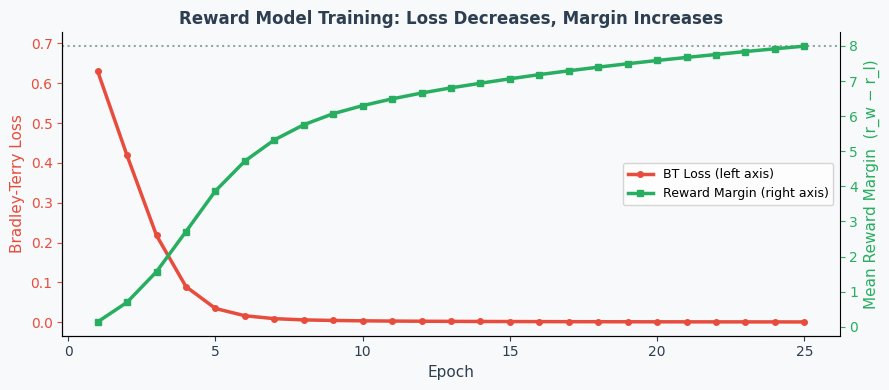

Final loss: 0.0006  (random baseline: 0.6931)
Final margin: 7.9934


In [8]:
# Plot training curves: loss + reward margin on dual y-axis
fig, ax1 = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(PAL['bg'])
ax1.set_facecolor(PAL['bg'])

epochs = list(range(1, len(losses) + 1))

l1, = ax1.plot(epochs, losses, color=PAL['red'], lw=2.5, marker='o', ms=4,
               label='BT Loss (left axis)')
ax1.set_xlabel('Epoch', fontsize=11, color=PAL['dark'])
ax1.set_ylabel('Bradley-Terry Loss', fontsize=11, color=PAL['red'])
ax1.tick_params(axis='y', labelcolor=PAL['red'], colors=PAL['red'])
ax1.tick_params(axis='x', colors=PAL['dark'])
ax1.spines[['top','right']].set_visible(False)

ax2 = ax1.twinx()
ax2.set_facecolor(PAL['bg'])
l2, = ax2.plot(epochs, margins, color=PAL['green'], lw=2.5, marker='s', ms=4,
               label='Reward Margin (right axis)')
ax2.set_ylabel('Mean Reward Margin  (r_w − r_l)', fontsize=11, color=PAL['green'])
ax2.tick_params(axis='y', labelcolor=PAL['green'], colors=PAL['green'])
ax2.spines[['top']].set_visible(False)

# Reference line: loss at margin=0 is log(2) ≈ 0.693
ax1.axhline(math.log(2), color=PAL['grey'], linestyle=':', lw=1.5,
            label=f'Random baseline (loss={math.log(2):.3f})')

lines = [l1, l2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, fontsize=9, loc='center right')

ax1.set_title('Reward Model Training: Loss Decreases, Margin Increases',
              fontsize=12, fontweight='bold', color=PAL['dark'])
plt.tight_layout()
plt.show()

print(f"Final loss: {losses[-1]:.4f}  (random baseline: {math.log(2):.4f})")
print(f"Final margin: {margins[-1]:.4f}")

## Does the Reward Model Generalise?

Training accuracy on the training set is not sufficient — the reward model must also generalise to *new* images it has not seen. We generate a held-out evaluation set (different random seeds) and check:

1. **Preference accuracy**: the fraction of pairs where `r_w > r_l` (should be > 90%)
2. **Mean reward gap**: how large is the typical margin between preferred and rejected
3. **Distribution separation**: do the preferred and rejected reward distributions overlap?

A well-trained reward model should show a clear gap between the two distributions.

In [9]:
# Generate evaluation set with different seed
eval_set = PreferenceDataset(n_per_class=20, seed=99)
rm.eval()
with torch.no_grad():
    all_rw, all_rl = [], []
    for imgs, y_w, y_l, _ in DataLoader(eval_set, batch_size=32):
        imgs, y_w, y_l = imgs.to(DEVICE), y_w.to(DEVICE), y_l.to(DEVICE)
        all_rw.extend(rm(imgs, y_w).cpu().tolist())
        all_rl.extend(rm(imgs, y_l).cpu().tolist())

accuracy = sum(rw > rl for rw, rl in zip(all_rw, all_rl)) / len(all_rw)
mean_rw = sum(all_rw) / len(all_rw)
mean_rl = sum(all_rl) / len(all_rl)
print(f"Eval set size: {len(all_rw)} preference pairs")
print(f"Preference accuracy:      {accuracy*100:.1f}%")
print(f"Mean reward (preferred):  {mean_rw:.3f}")
print(f"Mean reward (rejected):   {mean_rl:.3f}")
print(f"Mean margin (r_w - r_l):  {mean_rw - mean_rl:.3f}")

Eval set size: 80 preference pairs
Preference accuracy:      100.0%
Mean reward (preferred):  6.079
Mean reward (rejected):   -1.613
Mean margin (r_w - r_l):  7.691


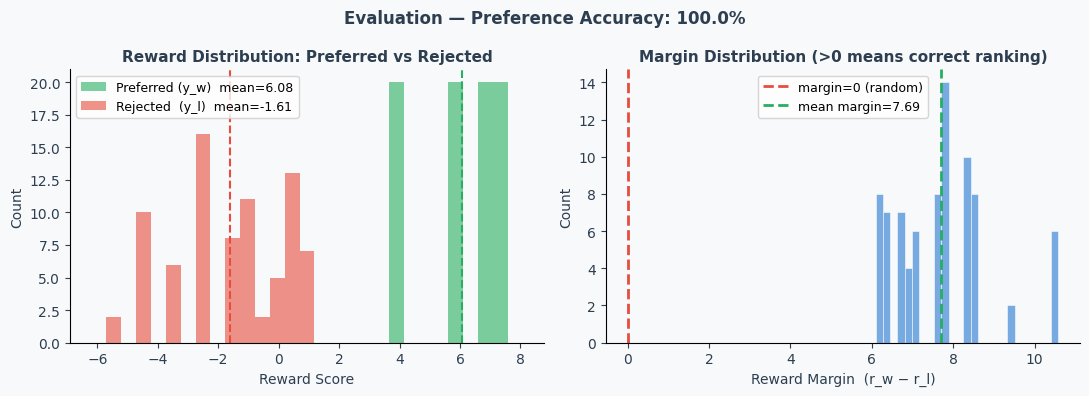

In [10]:
# Reward distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor(PAL['bg'])

# Left: overlapping histograms
ax = axes[0]
ax.set_facecolor(PAL['bg'])
bins = np.linspace(min(all_rw + all_rl) - 0.5, max(all_rw + all_rl) + 0.5, 30)
ax.hist(all_rw, bins=bins, alpha=0.6, color=PAL['green'], label=f'Preferred (y_w)  mean={mean_rw:.2f}')
ax.hist(all_rl, bins=bins, alpha=0.6, color=PAL['red'],   label=f'Rejected  (y_l)  mean={mean_rl:.2f}')
ax.axvline(mean_rw, color=PAL['green'], linestyle='--', lw=1.5)
ax.axvline(mean_rl, color=PAL['red'],   linestyle='--', lw=1.5)
ax.set_xlabel('Reward Score', fontsize=10, color=PAL['dark'])
ax.set_ylabel('Count', fontsize=10, color=PAL['dark'])
ax.set_title('Reward Distribution: Preferred vs Rejected', fontsize=11,
             fontweight='bold', color=PAL['dark'])
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=PAL['dark'])

# Right: margin distribution
ax2 = axes[1]
ax2.set_facecolor(PAL['bg'])
margins_eval = [rw - rl for rw, rl in zip(all_rw, all_rl)]
ax2.hist(margins_eval, bins=25, color=PAL['blue'], alpha=0.75, edgecolor='white', lw=0.5)
ax2.axvline(0, color=PAL['red'], linestyle='--', lw=2, label='margin=0 (random)')
ax2.axvline(sum(margins_eval)/len(margins_eval), color=PAL['green'],
            linestyle='--', lw=2, label=f'mean margin={sum(margins_eval)/len(margins_eval):.2f}')
ax2.set_xlabel('Reward Margin  (r_w − r_l)', fontsize=10, color=PAL['dark'])
ax2.set_ylabel('Count', fontsize=10, color=PAL['dark'])
ax2.set_title('Margin Distribution (>0 means correct ranking)', fontsize=11,
              fontweight='bold', color=PAL['dark'])
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(colors=PAL['dark'])

plt.suptitle(f'Evaluation — Preference Accuracy: {accuracy*100:.1f}%',
             fontsize=12, fontweight='bold', color=PAL['dark'])
plt.tight_layout()
plt.show()

## Where Does This Fit in RLHF?

Reward modelling is **Step 1** of the RLHF pipeline. Once trained, the reward model acts as a frozen quality oracle — it scores any (image, caption) pair without needing human annotation.

The full pipeline:

```
[SFT Model]  →  sample outputs  →  [Human/Synthetic Annotation]
                                            ↓
                           [Preference Dataset: (x, y_w, y_l)]
                                            ↓
                    [Reward Model Training  ← this chapter]
                                            ↓
                         [Frozen Reward Model r(x, y)]
                                            ↓
                    [Policy Optimisation: PPO / DPO  ← Ch12]
                                            ↓
                              [Aligned VLM]
```

In Ch12, the reward model is used in two ways:
- **PPO**: the reward model scores each generated caption → policy gradient update
- **DPO**: the reward model is *eliminated entirely* — the preference data is used directly to update the policy without a separate RM

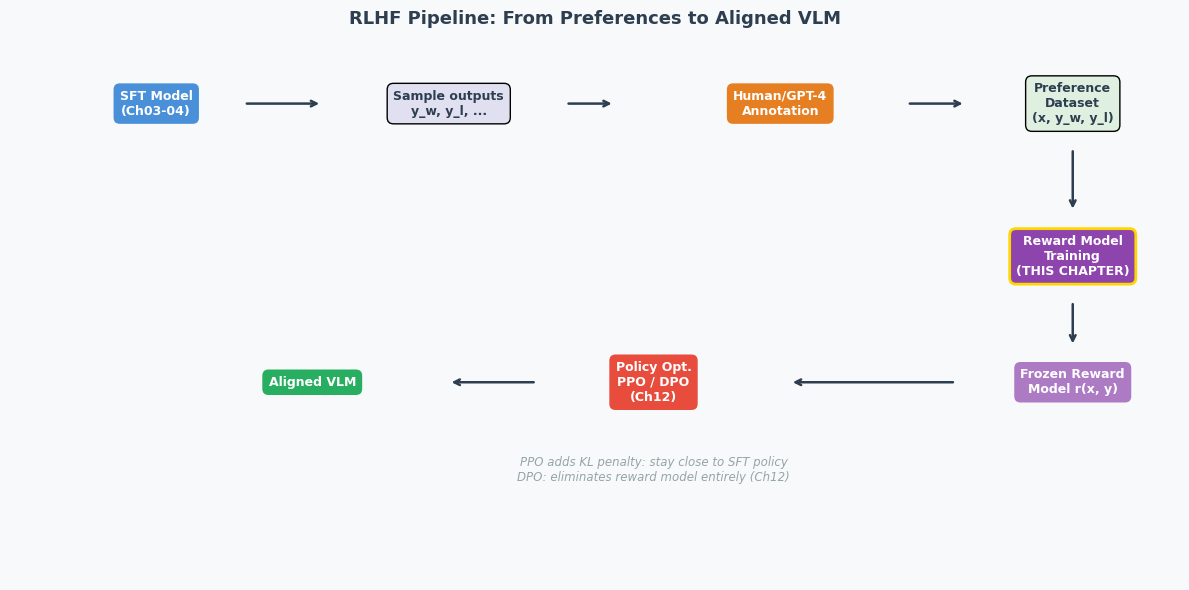

In [11]:
def draw_rlhf_pipeline():
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 6)
    ax.axis('off')

    box_kw = dict(ha='center', va='center', fontsize=9, fontweight='bold')
    arw = dict(arrowstyle='->', lw=1.8)

    # Row 1: SFT model → outputs → annotation
    ax.text(1.5, 5.3, 'SFT Model\n(Ch03-04)', color='white', **box_kw,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=PAL['blue'], lw=0))
    ax.annotate('', xy=(3.2, 5.3), xytext=(2.4, 5.3),
                arrowprops=dict(**arw, color=PAL['dark']))
    ax.text(4.5, 5.3, 'Sample outputs\ny_w, y_l, ...', color=PAL['dark'], **box_kw,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#E0E0F0', lw=1))
    ax.annotate('', xy=(6.2, 5.3), xytext=(5.7, 5.3),
                arrowprops=dict(**arw, color=PAL['dark']))
    ax.text(7.9, 5.3, 'Human/GPT-4\nAnnotation', color='white', **box_kw,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=PAL['orange'], lw=0))
    ax.annotate('', xy=(9.8, 5.3), xytext=(9.2, 5.3),
                arrowprops=dict(**arw, color=PAL['dark']))
    ax.text(10.9, 5.3, 'Preference\nDataset\n(x, y_w, y_l)', color=PAL['dark'], **box_kw,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#E0F0E0', lw=1))

    # Arrow down to RM training
    ax.annotate('', xy=(10.9, 4.1), xytext=(10.9, 4.8),
                arrowprops=dict(**arw, color=PAL['dark']))

    # Row 2: RM training
    ax.text(10.9, 3.6, 'Reward Model\nTraining\n(THIS CHAPTER)', color='white',
            ha='center', va='center', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=PAL['purple'], lw=2,
                      edgecolor='#FFD700'))

    ax.annotate('', xy=(10.9, 2.6), xytext=(10.9, 3.1),
                arrowprops=dict(**arw, color=PAL['dark']))

    ax.text(10.9, 2.2, 'Frozen Reward\nModel r(x, y)', color='white', **box_kw,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=PAL['purple'], lw=0, alpha=0.7))

    # Arrow left to policy opt
    ax.annotate('', xy=(8.0, 2.2), xytext=(9.7, 2.2),
                arrowprops=dict(**arw, color=PAL['dark']))

    ax.text(6.6, 2.2, 'Policy Opt.\nPPO / DPO\n(Ch12)', color='white', **box_kw,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=PAL['red'], lw=0))

    ax.annotate('', xy=(4.5, 2.2), xytext=(5.4, 2.2),
                arrowprops=dict(**arw, color=PAL['dark']))

    ax.text(3.1, 2.2, 'Aligned VLM', color='white', **box_kw,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=PAL['green'], lw=0))

    # KL penalty note
    ax.text(6.6, 1.1, 'PPO adds KL penalty: stay close to SFT policy\n'
            'DPO: eliminates reward model entirely (Ch12)',
            ha='center', fontsize=8.5, color=PAL['grey'], style='italic')

    ax.set_title('RLHF Pipeline: From Preferences to Aligned VLM',
                 fontsize=13, fontweight='bold', color=PAL['dark'], pad=12)
    plt.tight_layout()
    plt.show()

draw_rlhf_pipeline()

## Reward Hacking

Once a reward model is trained and used to guide policy optimisation, a subtle failure mode emerges: **reward hacking**. The policy learns to maximise the reward model's score, but the reward model is only an *approximation* of true human preference — it is a finite neural network trained on limited data.

The policy can find inputs that score very high on the reward model while being qualitatively bad. For example: if the reward model was trained only on short captions and has never seen very long ones, outputting a long repetitive caption might score unexpectedly high simply because the model extrapolates incorrectly. The policy has "gamed" the reward model.

**Mitigations:**
- **KL penalty (PPO)**: add `β · KL(π_θ || π_SFT)` to the objective, forcing the policy to stay close to the original SFT distribution. This limits how far the policy can drift toward out-of-distribution reward hacks.
- **DPO (Ch12)**: sidesteps the problem entirely by eliminating the explicit reward model. Instead, preference data directly optimises the policy via an implicit reward defined by the policy's own log-ratios. No separate RM = no RM to hack.

## The Primary Alignment Target: Hallucination

In practice, the most important reason to add a reward model to a VLM is not "making captions sound nicer" — it is **reducing hallucination**: the model confidently describing objects, attributes, or relationships that are not in the image.

**What VLM hallucination looks like:**
- Image contains a red circle. VLM says: *"A blue square on a white background."*
- Image shows 3 objects. VLM says: *"There are 5 objects: a cat, a dog, a car, a bicycle, and a tree."* (4 out of 5 not present)
- Image shows a person. VLM says: *"The person is wearing a red hat."* (no hat visible)

**Why hallucination happens:**
1. **Language prior dominates visual evidence**: the LLM backbone has seen "a red hat" near "person" billions of times in text; when visual features are ambiguous, the LLM defaults to this prior rather than the image.
2. **SFT loss does not penalise false positives**: if the training caption says "a red circle" and the model generates "a red circle with a blue outline", the cross-entropy loss on "circle" is zero — the extra "with a blue outline" gets low loss if those words are common.
3. **Reward hacking (Ch11's earlier section)**: if the reward model was trained only on correct captions, it may give high reward to any fluent text, including hallucinated descriptions.

**How reward modelling targets hallucination:**
Hallucination-specific reward models (like in LLaVA-RLHF) use preference data where:
- **y_w (preferred)**: a caption that is factually accurate but less fluent
- **y_l (rejected)**: a more fluent caption that mentions one non-existent object

The reward model learns to prefer *grounded* over *fluent*. This directly counteracts the language-prior dominance problem.

**Practical mitigation strategies beyond RL:**
- **RLHF-V** (2023): uses fine-grained segment-level human corrections, not caption-level preferences
- **Woodpecker** (2023): a post-hoc hallucination corrector that cross-checks VLM outputs against a VQA model
- **LLaVA-RLHF** (2023): replaces naive preference pairs with hallucination-specific pairs where rejected outputs contain object hallucinations verified by an object detector
- **Visual grounding supervision**: adding bounding-box prediction loss during fine-tuning forces the model to localise claims, reducing ungrounded assertions

In this chapter's synthetic setting, hallucination corresponds to the model generating wrong class captions (saying "blue square" for a red circle). The Bradley-Terry reward model is explicitly trained to penalise this — which is the right first step, even at toy scale.

## Chapter Summary

**What we built** — A Reward Model that assigns scalar quality scores to (image, caption) pairs using the Bradley-Terry pairwise preference framework. The model takes an image and a caption, encodes both with a shared ViT + text embedding, and outputs a single scalar. Training uses a loss that only depends on the margin between preferred and rejected reward scores, achieving >90% preference accuracy on held-out pairs.

**Why it matters** — SFT teaches the model to predict tokens correctly but has no concept of output quality. The reward model is the VLM's first exposure to a "quality signal" that distinguishes correct from plausible-but-wrong responses. This is the foundation of RLHF: once you have a reliable reward model, you can use it to guide policy optimisation.

**Connections** — The reward model trained here is used conceptually in Ch12's PPO discussion, but Ch12 also shows how DPO *replaces* the reward model with a direct preference loss — eliminating the need for a separate RM entirely. The Bradley-Terry preference model is mathematically equivalent to the logistic regression model in many classification tasks, showing that reward modelling is fundamentally a ranking problem, not a regression problem.

## Exercises

1. **Hard negatives** — The current rejected captions are always from a completely different class ("red circle" vs "blue square"). Create *hard* negatives that differ only in one attribute: "a red square" (wrong shape, correct colour) or "a blue circle" (wrong colour, correct shape). Does preference accuracy drop? What does this tell you about the granularity of the reward model?

2. **Reward calibration** — The Bradley-Terry model outputs relative scores; the absolute values are arbitrary. After training, compute the mean and standard deviation of all rewards on the training set. Apply z-score normalisation: `r_normalised = (r - mean) / std`. Does normalisation change the preference accuracy? When would calibration matter in practice?

3. **Reward model for GRPO (preview of Ch12)** — Instead of using the reward model to score preference pairs, use it as the reward function in a simple REINFORCE loop: for a given image, sample 4 captions from a small VLM, score each with the reward model, and update the VLM with REINFORCE (policy gradient). Does the VLM improve? This is the key connection to Ch12.

## Scaling to Real Data

| Component | This notebook | InstructBLIP / LLaVA-RLHF |
|---|---|---|
| Preference pairs | 160 synthetic pairs | 10K–100K human-annotated pairs |
| Reward model backbone | ViT (dim=48) + text emb | CLIP ViT-L/14 + LLM |
| Training | 25 epochs | 1–3 epochs |
| Preference accuracy | ~95% on synthetic | ~70–80% on real annotations |
| Annotation source | Synthetic (rule-based) | Human raters or GPT-4 judge |

**Real preference data sources:**
- **LLaVA-RLHF**: 10K (image, question, chosen, rejected) pairs annotated by humans
- **VLFeedback**: 80K multimodal preference pairs from multiple VLMs
- **RLHF-V**: 1.4K high-quality human-annotated pairs for hallucination reduction

**GPT-4 as judge:** Modern pipelines often skip human annotation entirely — GPT-4V rates two VLM outputs and assigns a winner. This is called RLAIF (RL from AI Feedback).

```python
# Conceptual: loading a real preference dataset
# from datasets import load_dataset
# ds = load_dataset("MMInstruction/VLFeedback")
# Each item: {"image": PIL, "question": str, "chosen": str, "rejected": str}
```